In [1]:
import math
from collections import namedtuple
from os import W_OK
from pathlib import Path

import numpy as np
from fluids.atmosphere import ATMOSPHERE_1976

import openvsp as vsp
from pathlib import Path

from matplotlib import pyplot as plt

from assignment1.utils.vsp_manager import VspManager, AnalysisSettings


In [ ]:
#to_get = ['Alpha', 'CLtot']#, 'CDtot']
to_get = ['Alpha', 'CLtot', 'CDtot', 'CLwtot', 'CDwtot']

vsp_file = Path('wing_assignment.vsp3')
aero_path = Path('~/Downloads/OpenVSP-3.48.1-win64').expanduser()
manager = VspManager(aero_path, vsp_file)

analysis_name = "VSPAEROSweep"

manager.setup_analysis()

## Task 1

Calculate the drag polar and $C_L$ vs $\alpha$ with 20 panels in x and y directions

I also cheated a bit and created this airfoil in a GUI, and then saved as `wing_assignment.vsp3`

To get a Reynolds number of $3.0 \cdot 10^{6}$ the following parameters are used
* Air: standard conditions
* Chord: 400 (mm)
* Wingspan: 2000 (mm)
* Airspeed: 40 (m/s)
* Mach number: 0.118
* 20 panels in chord- and span-wise directions


SETUP 1
SETUP 2


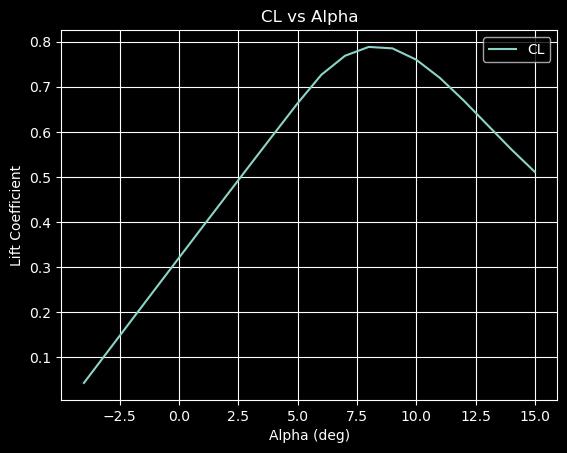

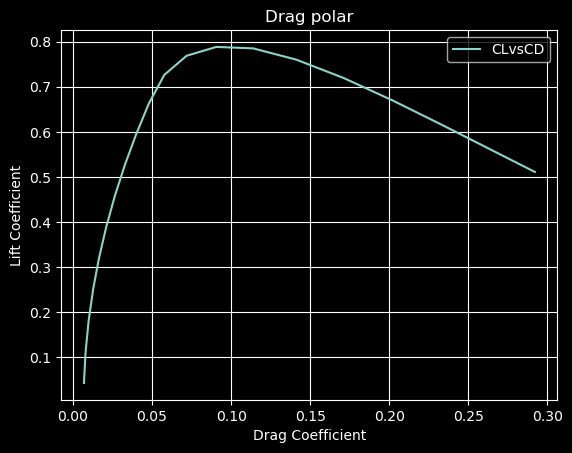

In [10]:
manager.set_simulation_setting(AnalysisSettings(geom="WingGeom", analysis=analysis_name, name="SectTess_U"), 20)
manager.set_simulation_setting(AnalysisSettings(geom="WingGeom", analysis=analysis_name, name="Tess_W"), 20)

data_t1 = manager.perform_analysis(analysis_name, to_get)

plt.plot(data_t1['Alpha'], data_t1['CLtot'], label="CL")
plt.xlabel("Alpha (deg)")
plt.ylabel("Lift Coefficient")
plt.title("CL vs Alpha")
plt.legend()
plt.grid()
plt.show()

plt.plot(data_t1['CDtot'], data_t1['CLtot'], label="CLvsCD")
plt.xlabel("Drag Coefficient")
plt.ylabel("Lift Coefficient")
plt.title("Drag polar")
plt.legend()
plt.grid()
plt.show()


In [77]:
import math
CL_alpha_AR5 = (data_t1['CLtot'][9]-data_t1['CLtot'][4])/math.radians(data_t1['Alpha'][9]-data_t1['Alpha'][4])
CL_alpha_AR5

3.929201405284349

By the visual inspection, the results look good; there is a nice and linear $C_L$ increase up to the stall AoA and then there is a sudden drop which is accompanied by skyrocketing drag.

However, the $C_{Lmax}$ reaches 0.78 at 8 degrees as compared to 1.65 at 14 degrees in the experimental data from NACA report 824.

Moreover, the $\frac{\partial C_L}{\partial \alpha}$ is at 3.92 as compared to 6.08 as per the experimental report.

One possible explanation could be that this is a relatively low-AR finite wing, while the report deals with airfoil sections.

What is strange is that the maximum AoA is also lower for the finite wing, which should not be the case because of downwash reducing the effective AoA.



## Task 2
This one takes quite some time to complete, some 15ish minutes on my machine.

The plan is to first sweep through chordwise panel counts, then, through the spanwise counts, and then through both at the same time

To determine the best combination the "Elbow" method from Machine Learning is used, in essence, finding the best bang for the buck.
For that effect, evaluate
* The change in the solution itself, calculated as $L^1$ norm of the difference
* The change in the computation complexity, which is proportional to the total number of panels.
* With those two changes, a derivative could be computed, and when it becomes small, we could decide that we entered the area of diminishing returns, and it makes little sense to refine the mesh further.

P.S. this task is one of the most CPU-frying tasks of this assignment. The three cells below take a long time to run. It's normal.

In [50]:
DEFAULT_U = 5
DEFAULT_W = 5
MAX_U = 90
MAX_W = 90
N_POINTS = 6

manager.set_simulation_setting(AnalysisSettings(geom="WingGeom", analysis=analysis_name, name="SectTess_U"), DEFAULT_U)
manager.set_simulation_setting(AnalysisSettings(geom="WingGeom", analysis=analysis_name, name="Tess_W"), DEFAULT_W)

_as1 = AnalysisSettings(geom="WingGeom", analysis=analysis_name, name="SectTess_U", start=DEFAULT_U, end=MAX_U, num=N_POINTS)
_as2 = AnalysisSettings(geom="WingGeom", analysis=analysis_name, name="Tess_W", start=DEFAULT_W, end=MAX_W, num=N_POINTS)
data_t2_chord = manager.sweep_analysis(_as1, to_get)

SETUP 1
SETUP 2
SETUP 1
SETUP 2
SETUP 1
SETUP 2
SETUP 1
SETUP 2
SETUP 1
SETUP 2
SETUP 1
SETUP 2
SETUP 1
SETUP 2
SETUP 1
SETUP 2
SETUP 1
SETUP 2
SETUP 1
SETUP 2
SETUP 1
SETUP 2


In [48]:
manager.set_simulation_setting(AnalysisSettings(geom="WingGeom", analysis=analysis_name, name="SectTess_U"), DEFAULT_U)
manager.set_simulation_setting(AnalysisSettings(geom="WingGeom", analysis=analysis_name, name="Tess_W"), DEFAULT_W)

data_t2_span = manager.sweep_analysis(_as2, to_get)

SETUP 1
SETUP 2
SETUP 1
SETUP 2
SETUP 1
SETUP 2
SETUP 1
SETUP 2
SETUP 1
SETUP 2
SETUP 1
SETUP 2
SETUP 1
SETUP 2
SETUP 1
SETUP 2
SETUP 1
SETUP 2
SETUP 1
SETUP 2
SETUP 1
SETUP 2


In [ ]:
data_t2_both = manager.parallel_sweep_analysis([_as1, _as2], to_get)

SETUP 1
SETUP 2
SETUP 1
SETUP 2
SETUP 1
SETUP 2
SETUP 1
SETUP 2
SETUP 1
SETUP 2
SETUP 1
SETUP 2
SETUP 1
SETUP 2
SETUP 1
SETUP 2
SETUP 1
SETUP 2
SETUP 1
SETUP 2
SETUP 1
SETUP 2
SETUP 1
SETUP 2
SETUP 1
SETUP 2
SETUP 1
SETUP 2
SETUP 1
SETUP 2
SETUP 1
SETUP 2


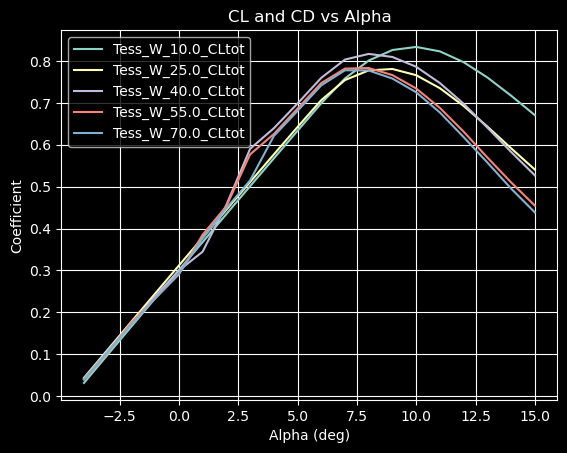

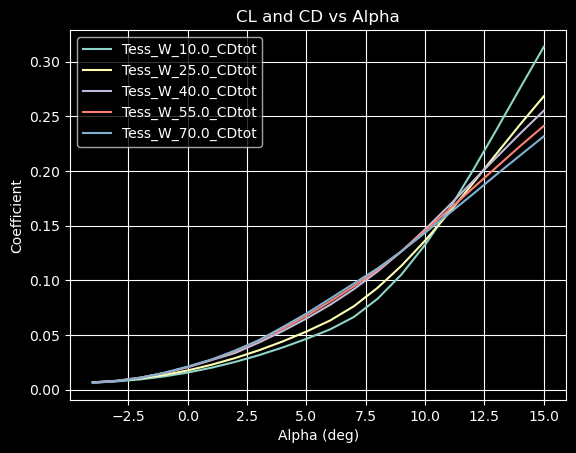

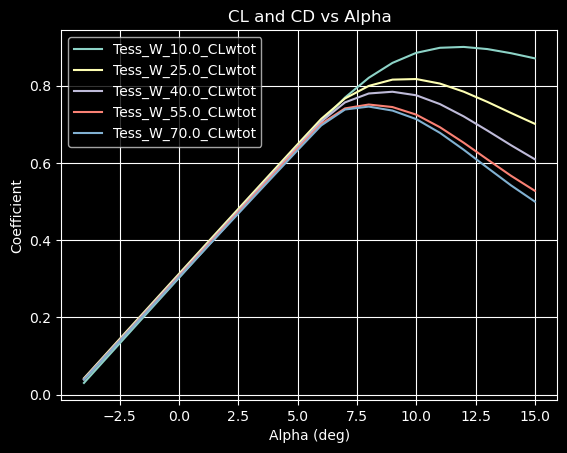

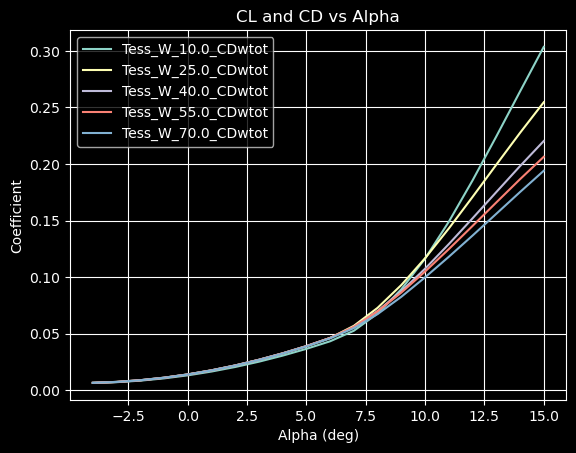

In [58]:
alphas = data_t1['Alpha']
for plot_label in to_get[1:]:
    for k,v in data_t2_span.items():
        for label, data_t2 in v.items():
            if plot_label == label:
                plt.plot(alphas, data_t2, label=f"{k}_{label}")
    plt.xlabel("Alpha (deg)")
    plt.ylabel("Coefficient")
    plt.title("CL and CD vs Alpha")
    plt.legend()
    plt.grid()
    plt.show()

Looks like the mesh size does not change the things significantly, but let's quantify that statement

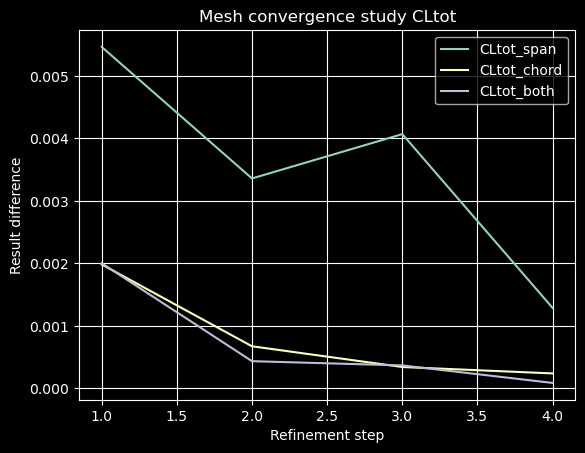

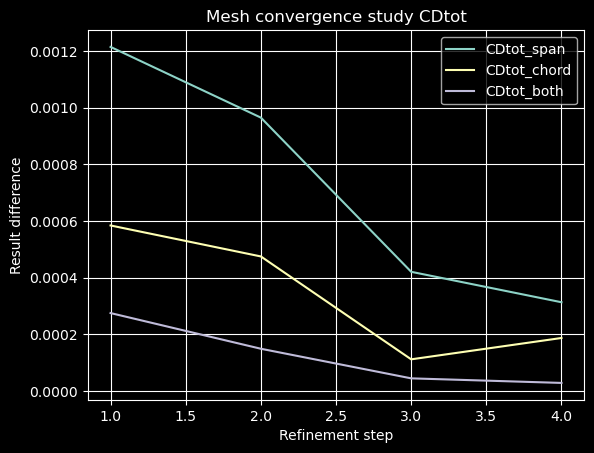

In [64]:
import numpy as np

n_panel_span = DEFAULT_W * np.linspace(_as2.start, _as2.end, N_POINTS, dtype=int)
n_panel_chord = DEFAULT_U * np.linspace(_as1.start, _as1.end, N_POINTS, dtype=int)
n_panel_both = np.linspace(_as2.start, _as2.end, N_POINTS, dtype=int) * np.linspace(_as1.start, _as1.end, N_POINTS, dtype=int)

for graph in ['CLtot', 'CDtot']:
    for label, data, counts in zip(['span', 'chord', 'both'], [data_t2_span, data_t2_chord, data_t2_both], [n_panel_span, n_panel_chord, n_panel_both]):
        data_diff = np.sum(np.abs(np.diff([v[graph] for k, v in data.items()], axis=0)), axis=1)
        plt.plot(range(1, N_POINTS), data_diff / np.diff(counts), label=f"{graph}_{label}")

    plt.xlabel("Refinement step")
    plt.ylabel("Result difference")
    plt.title(f"Mesh convergence study: {graph}")
    plt.legend()
    plt.grid()
    plt.show()


The refinement step 3 will be chosen for both span- and chord-wise panel counts, which amounts to 40 panels each

In [86]:
CHOSEN_STEP = 2

## Task 3

How the do I set thin/thick? No idea here

## Task 4
Let's bump the wingspan to 3200mm to increase the AR to 8, and see what happens

The $C_{L,\alpha}$ will be calculated with a simple finite difference from the linear region, and the theoretical $C_{L,\alpha}$ could be found as $$C_{L,\alpha} = C_{l,\alpha} \frac{AR}{\frac{C_{l,\alpha}}{\pi} + \sqrt{(\frac{C_{l,\alpha}}{\pi})^2 + AR^2}}$$

Where the $C_{l,\alpha}$ could be found from the NACA report 824

The resulting theoretical lift slope is equal to 4.78

Let's just say that it is not good. It is terrible, in fact.

SETUP 1
SETUP 2


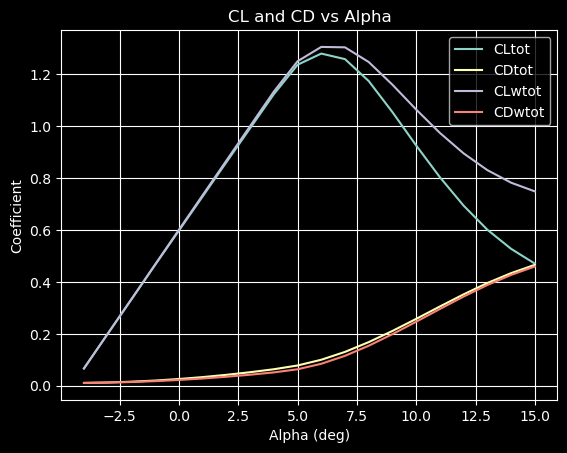

In [87]:


manager.set_simulation_setting(AnalysisSettings(geom="WingGeom", analysis=analysis_name, name="TotalProjectedSpan"), 3200)
manager.set_simulation_setting(AnalysisSettings(geom="WingGeom", analysis=analysis_name, name="TotalSpan"), 3200)
manager.set_simulation_setting(AnalysisSettings(geom="WingGeom", analysis=analysis_name, name="SectTess_U"), int(np.linspace(_as1.start, _as1.end, N_POINTS, dtype=int)[CHOSEN_STEP]))
manager.set_simulation_setting(AnalysisSettings(geom="WingGeom", analysis=analysis_name, name="Tess_W"), int(np.linspace(_as2.start, _as2.end, N_POINTS, dtype=int)[CHOSEN_STEP]))


result = manager.perform_analysis(analysis_name, to_get)
alphas = result.pop('Alpha')
for label, data in result.items():
    plt.plot(alphas, data, label=label)
plt.xlabel("Alpha (deg)")
plt.ylabel("Coefficient")
plt.title("CL and CD vs Alpha")
plt.legend()
plt.grid()
plt.show()

In [83]:
# Just a crude finite difference
import math
AR = 8
Cl_alpha = 6.0876765733
CL_alpha = (result['CLtot'][8] - result['CLtot'][3]) / (math.radians(alphas[8] - alphas[3]))
CL_alpha_theoretical = Cl_alpha * AR / (Cl_alpha / math.pi + math.sqrt((Cl_alpha / math.pi) ** 2 + AR ** 2))
CL_alpha_theoretical

4.789153446267931